In [54]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

import matplotlib.pyplot as plt

import io
from IPython.display import Image, display
import utils
import nist_codes

import matplotlib.patheffects as pe

import new_utils


import nist_helper

from PIL import Image as PILImage

In [55]:
H_SHEET = "h test.xlsx"

global df  
df = pd.read_excel(H_SHEET)
new_utils.res_col_names(data_df=df, nm_col=None, int_col=None)

data_df = df

nm Grey Val


In [56]:
# default df_filtered
df_filtered = df[(df[new_utils.wl_col] >= 400) & (df[new_utils.wl_col] <= 750)].copy()
df_filtered = df_filtered.sort_values(by=new_utils.wl_col).reset_index(drop=True)
print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())


# smoothed df_filtered
df_filtered['Smoothed_int'] = df_filtered[new_utils.INT_col].rolling(window=new_utils.smoothing_window, center=True).mean().fillna(df_filtered[new_utils.INT_col])

if new_utils.plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered[new_utils.INT_col].min()
    max_int = df_filtered[new_utils.INT_col].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if new_utils.plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered[new_utils.INT_col] - min_int) / int_range


detection_col = '_raw_int'
int_col = '_adj_int'

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm
0         NaN     8.367  774.51129
1         NaN     9.796  773.38503
2         NaN     9.329  772.25877
3         NaN     9.808  771.13251
4         NaN     9.646  770.00625


In [57]:
def get_generic_type():
    global generic_type
    gen_type = (input('Choose Rendering: Raw or Normalised')).lower()
    if gen_type == 'raw' or gen_type == 'r':
        generic_type = 'raw'
    elif gen_type == 'normalised' or gen_type == 'norm' or gen_type == 'n':
        generic_type = 'normalised'
    
    print (generic_type)
    return generic_type

In [58]:
# raw vs normalised and peak label positioning breaks when function is used

def set_generic_type():
    get_generic_type()
    if generic_type == 'raw':
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        prominence_percentage = utils.DEFAULT_PROM_PERC
        _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
        min_brightness = utils.DEFAULT_MIN_BRIGHT
    elif generic_type == 'normalised':
        _peak_emphasis = utils.NORM_PEAK_EMPHASIS
        min_brightness = utils.NORM_MIN_BRIGHT
        prominence_percentage = utils.NORM_PROM_PERC
        glow_alpha = utils.NORM_GLOW_ALPHA
        peak_label_y_position = utils.NORM_PEAK_LABEL_POSN

    return glow_alpha, peak_label_y_position, prominence_percentage, _peak_emphasis, min_brightness


In [59]:
# ax. ... values don't pass when trad_spec_labels() is called

# function is now just for setting mode

def trad_spec_labels():
    new_utils.get_mode()
    new_utils.text_colour()

    global figure_bg_color
    global text_color
    
    if new_utils.mode == 'dark':
        figure_bg_color = 'black'
        text_color = new_utils.colour
    elif new_utils.mode == 'light':
        figure_bg_color = 'white'
        text_color = new_utils.colour
    print("mode:", new_utils.mode, ", fig bg colour:", figure_bg_color)

In [60]:
# cause spec to show too many peaks

def has_any_nist(
    data_df,
    force_nist = None,
    nm_col = None,
    int_col = None,
    
):
    new_utils.res_col_names(data_df, nm_col=nm_col, int_col=int_col)

    global df_plot_data
    df_plot_data = data_df.copy()
    df_plot_data[new_utils.wl_col] = pd.to_numeric(df_plot_data[new_utils.wl_col], errors='coerce')

    nist_diag = nist_codes.detect_nist_values(df_plot_data[new_utils.INT_col], force_nist = force_nist)
    return nist_diag, df_plot_data

In [61]:
# breaks code whenever used

def vals_by_gen_type(
    data_df,
    apply_descriptor_adjustments = False,
    min_brightness = 0,
    prominence_percentage = 0,
    glow_alpha = 0,
    force_nist = None,
    peak_label_y_position = 0,
    fig_size = (15,3),
    dpi = utils.DPI,

):
    
    has_any_nist(data_df)

    global df_plot_data
    
    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')
        generic_type = (input('Choose Rendering: Raw or Normalised')).lower()
        if generic_type == 'raw' or generic_type == 'r':
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised' or generic_type == 'n':
            glow_alpha = utils.NORM_GLOW_ALPHA
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN





    return min_brightness, glow_alpha, prominence_percentage, peak_label_y_position, has_any_nist

In [62]:
def prep_nist_spec(
    data_df,
    nm_col ,
    int_col,
    force_nist,
    apply_descriptor_adjustments,
    x_min,
    x_max,

):

    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        print('NIST Descriptors Detected. Preparing NIST Rendering.')
    else:
        print('No NIST Descriptors Detected. Ending NIST Rendering.')
        # Return None for the data, and True for the "should exit early" flag
        return None, True

    # parse NIST-style cells (Fixed the lambda indexes here!)
    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty flag for empty datasets
    if df_plot_data.empty:
        return None, True 

    if nist_helper is not None:
        effs = df_plot_data['_descriptor'].apply(lambda d: nist_codes._effects_from_desc(d))
        df_plot_data['_intensity_mult'] = effs.apply(lambda x: x[0])
        df_plot_data['_width_mult'] = effs.apply(lambda x: x[1])
        df_plot_data['_include'] = effs.apply(lambda x: x[2])
        df_plot_data = df_plot_data[df_plot_data['_include']].copy()
    else:
        df_plot_data['_intensity_mult'] = 1.0
        df_plot_data['_width_mult'] = 1.0

    # Create adjusted intensity column used for normalization/detection
    if apply_descriptor_adjustments:
        df_plot_data['_adj_int'] = df_plot_data['_raw_int'] * df_plot_data['_intensity_mult']
    else:
        df_plot_data['_adj_int'] = df_plot_data['_raw_int']

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    # Success! Return the completed dataframe and False (do not exit early)
    return df_plot_data, False


In [63]:
def trad_spec(
    data_df,
    prominence_percentage=0,
    nm_col = None,
    int_col = None,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    fig_size=utils.FIG_SIZE,
    min_brightness=0,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=utils.DPI,
    peak_label_y_position=0,
    max_needle_y_scale=utils.MAX_Y_SCALE,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=utils.LABEL_NORM_INT,

):

    trad_spec_labels()
    
    new_utils.res_col_names(data_df, nm_col=nm_col, int_col=int_col)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[new_utils.wl_col] = pd.to_numeric(df_plot_data[new_utils.wl_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[new_utils.INT_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')
        get_generic_type()
        if generic_type == 'raw':
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised' or generic_type == 'n':
            glow_alpha = utils.NORM_GLOW_ALPHA
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN

        # parse NIST-style cells
    parsed_intensity = df_plot_data[new_utils.INT_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[new_utils.wl_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[new_utils.wl_col] >= x_min) & (df_plot_data[new_utils.wl_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=new_utils.wl_col).reset_index(drop=True)
    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    if peak_wavelengths is not None:
        nm_vals = df_plot_data[new_utils.wl_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw' or generic_type == 'r':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if generic_type == 'normalised' or generic_type == 'n':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[new_utils.INT_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][new_utils.wl_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)
    
    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")


    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)


    max_label_y = max(label_ys) if label_ys else peak_label_y_position
    print(f"DEBUG: max_label_y = {max_label_y:.3f}, fig height = {fig.get_figheight():.2f}")

    # More aggressive expansion
    ylim_upper = max(1.05, max_label_y + 0.25)
    ax.set_ylim(0, ylim_upper)
    fig.set_figheight(fig_size[1] + 0.8)
    print(f"DEBUG: new ylim upper = {ylim_upper:.3f}, new fig height = {fig.get_figheight():.2f}")



    fig.patch.set_facecolor(figure_bg_color)

    ax.set_facecolor('black')  
    ax.yaxis.set_visible(False)

    ax.set_xlabel(new_utils.x_title, color=text_color)

    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0,1)


    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[new_utils.wl_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = new_utils.rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][new_utils.wl_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = new_utils.rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw' or generic_type == 'r':
            _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = utils.DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised' or generic_type == 'norm' or generic_type == 'n':
            _peak_emphasis = utils.NORM_PEAK_EMPHASIS
            min_brightness = utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.title(f'{generic_type.capitalize()} Emission Spectrum Visualization ({new_utils.mode.capitalize()} Mode)', 
          color=new_utils.colour, y=0.98, pad=pad)


    plt.close(fig)
    return fig

mode: dark
text colour: white face/bg colour: black
mode: dark , fig bg colour: black
nm Grey Val
No NIST Destriptors Detected. Preparing Generic Rendering.
raw
DEBUG: max_label_y = 0.77
DEBUG: max_label_y = 0.770, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80


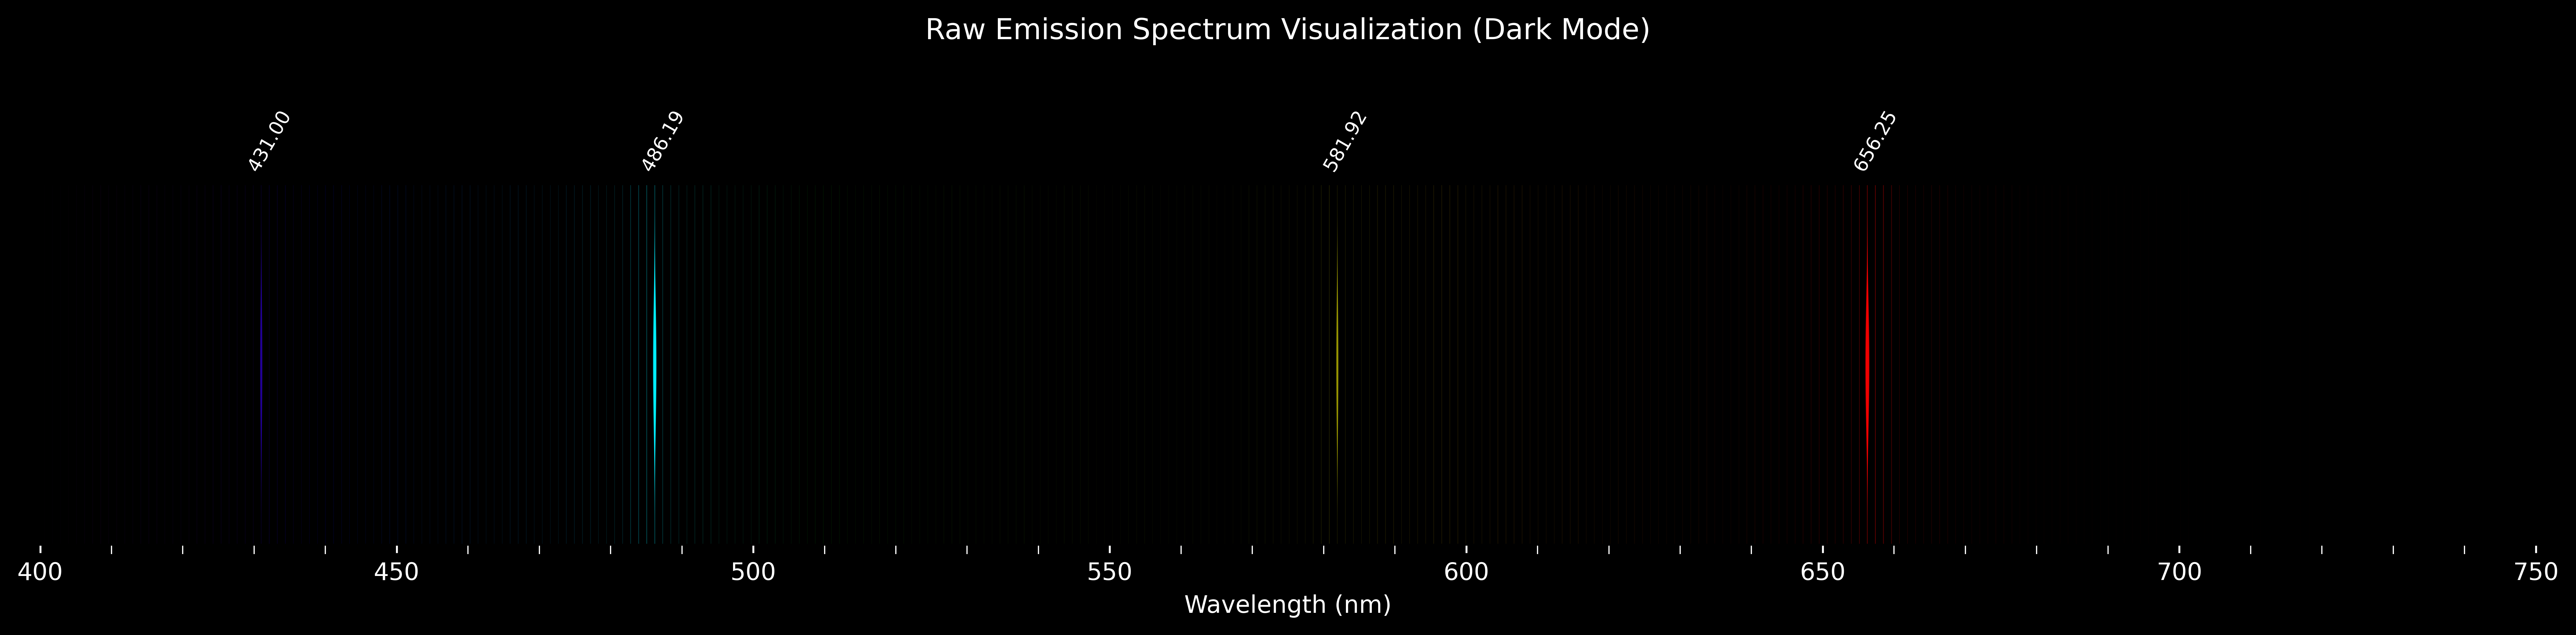

In [64]:
trad_spec(data_df)

In [65]:
def plot(
        
    df_plot_data,
    nm_col,

    prominence_percentage=0.08,

    fig_size=(15, 3),
    min_brightness=0.1,

    min_needle_max_width_nm=0.1,
    max_needle_max_width_nm=0.3,
    needle_shape_power=4,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    dpi=600,

    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    peak_wavelengths=None,
    show_peak_labels=True,
    label_min_norm_int=0.20,
):

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    # --- Peak Detection (raw data) ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for peak_wavelength in peak_wavelengths:
            try:
                target_nm = float(peak_wavelength)
            except Exception:
                continue
            peaks.append(int(np.argmin(np.abs(nm_vals - target_nm))))
        peaks = sorted(set(peaks))
    else:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)

    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        _peak_emphasis = 1.4
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_int_scale,
            base_rgb[1] * final_int_scale,
            base_rgb[2] * final_int_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    return fig, ax

In [66]:
def nist_spec(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0.08,
    x_min=400,
    x_max=750,
    fig_size=(15, 3),
    min_brightness=0.1,
    min_needle_max_width_nm=0.1,
    max_needle_max_width_nm=0.3,
    needle_shape_power=4,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    dpi=600,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=0.20,
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    df_plot_data, should_exit_early, has_any_nist = prep_nist_spec(data_df = data_df, nm_col = nm_col, int_col = int_col, force_nist = force_nist, apply_descriptor_adjustments=apply_descriptor_adjustments, x_min = x_min, x_max = x_max)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending NIST Rendering Early.")
        return fig

    # Detection must always use raw numeric intensities; rendering uses adjusted values.
    detection_col = '_raw_int'
    int_col = '_adj_int'  # used for normalization/rendering


    fig, ax = plot(df_plot_data = df_plot_data, nm_col = nm_col, has_any_nist=has_any_nist)

    # Create the plot (use explicit Figure/Axis to avoid side-effects)


    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    # Set a fixed y-range for the vertical lines to appear as a bar
    ax.set_ylim(0, 1)
   


    plt.title(f'NIST Emission Spectrum Visualization ({mode.capitalize()} Mode)', color=text_color, y=1.0, pad=10)

    return fig

In [67]:
SHEET = "oxygen nist 2.xlsx"
d_df = pd.read_excel(SHEET)

nist_spec(d_df)

NIST Descriptors Detected. Preparing NIST Rendering.


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
def left_x(a, b):
    xleft = a - b / 2
    return xleft

def right_x(a, b):
    xright = a + b / 2
    return xright

In [ ]:
def plot_nist_spec(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0.08,
    x_min=400,
    x_max=750,
    fig_size=(15, 3),
    min_brightness=0.1,
    min_needle_max_width_nm=0.1,
    max_needle_max_width_nm=0.3,
    needle_shape_power=4,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    dpi=600,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=0.20,
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data.empty
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print('No NIST Destriptors Detected. Ending NIST Rendering.')
        return fig

    # parse NIST-style cells
    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig 

    if nist_helper is not None:
        effs = df_plot_data['_descriptor'].apply(lambda d: nist_codes._effects_from_desc(d))
        df_plot_data['_intensity_mult'] = effs.apply(lambda x: x[0])
        df_plot_data['_width_mult'] = effs.apply(lambda x: x[1])
        df_plot_data['_include'] = effs.apply(lambda x: x[2])
        df_plot_data = df_plot_data[df_plot_data['_include']].copy()
    else:
        df_plot_data['_intensity_mult'] = 1.0
        df_plot_data['_width_mult'] = 1.0

    # Create adjusted intensity column used for normalization/detection
    if apply_descriptor_adjustments:
        df_plot_data['_adj_int'] = df_plot_data['_raw_int'] * df_plot_data['_intensity_mult']
    else:
        df_plot_data['_adj_int'] = df_plot_data['_raw_int']

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    # Detection must always use raw numeric intensities; rendering uses adjusted values.
    detection_col = '_raw_int'
    int_col = '_adj_int'  # used for normalization/rendering

    # --- Peak Detection (raw data) ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for peak_wavelength in peak_wavelengths:
            try:
                target_nm = float(peak_wavelength)
            except Exception:
                continue
            peaks.append(int(np.argmin(np.abs(nm_vals - target_nm))))
        peaks = sorted(set(peaks))
    else:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)

    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)


    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    # Set a fixed y-range for the vertical lines to appear as a bar
    ax.set_ylim(0, 1)
   
    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = new_utils.final_scale(min_brightness, _ni)
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = new_utils.dynamic_prominence(_bg_base_width, np.ones_like(_bg_y))
        _x_left = left_x(_nm, _bg_widths)
        _x_right = right_x(_nm, _bg_widths)
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        _peak_emphasis = 1.4
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = left_x(peak_nm, glow_current_widths_nm)
        glow_x_right = right_x(peak_nm, glow_current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = new_utils.dynamic_prominence(scaled_max_width_nm, width_profile_factor)
        x_left = left_x(peak_nm, current_widths_nm)
        x_right = right_x(peak_nm, current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    plt.title(f'NIST Emission Spectrum Visualization ({mode.capitalize()} Mode)', color=text_color, y=1.0, pad=10)


    return fig

NIST Destriptors Detected. Preparing NIST Rendering.


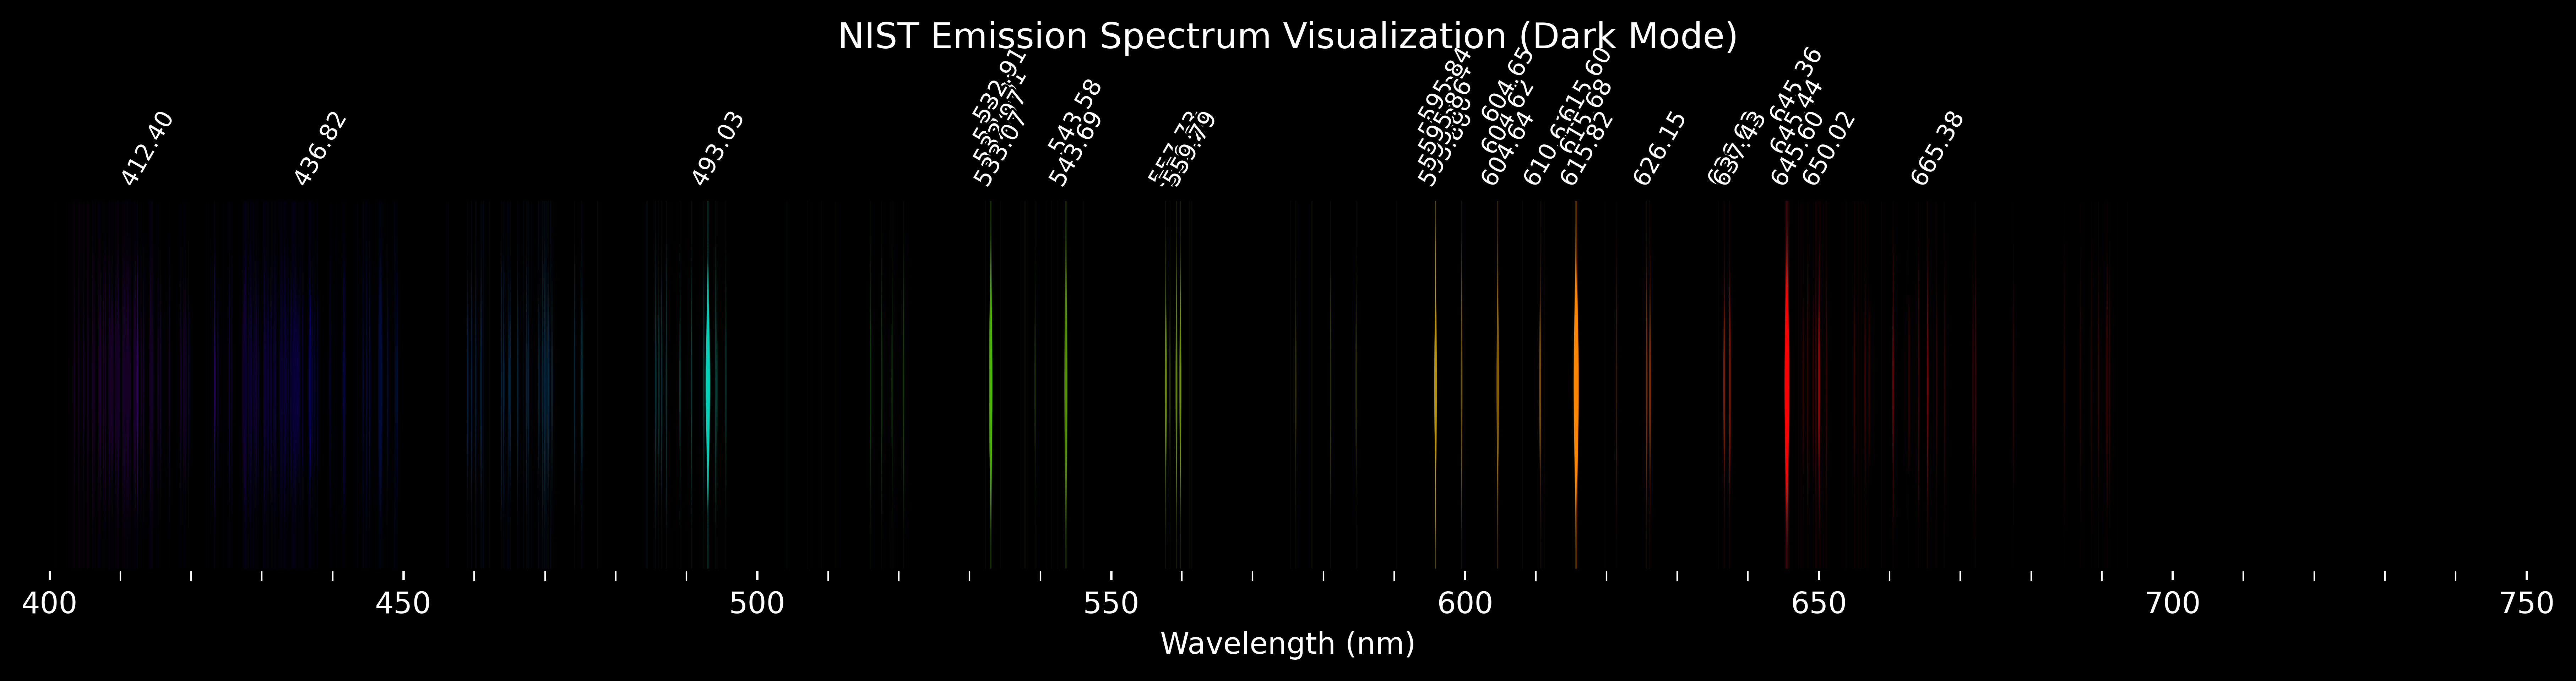

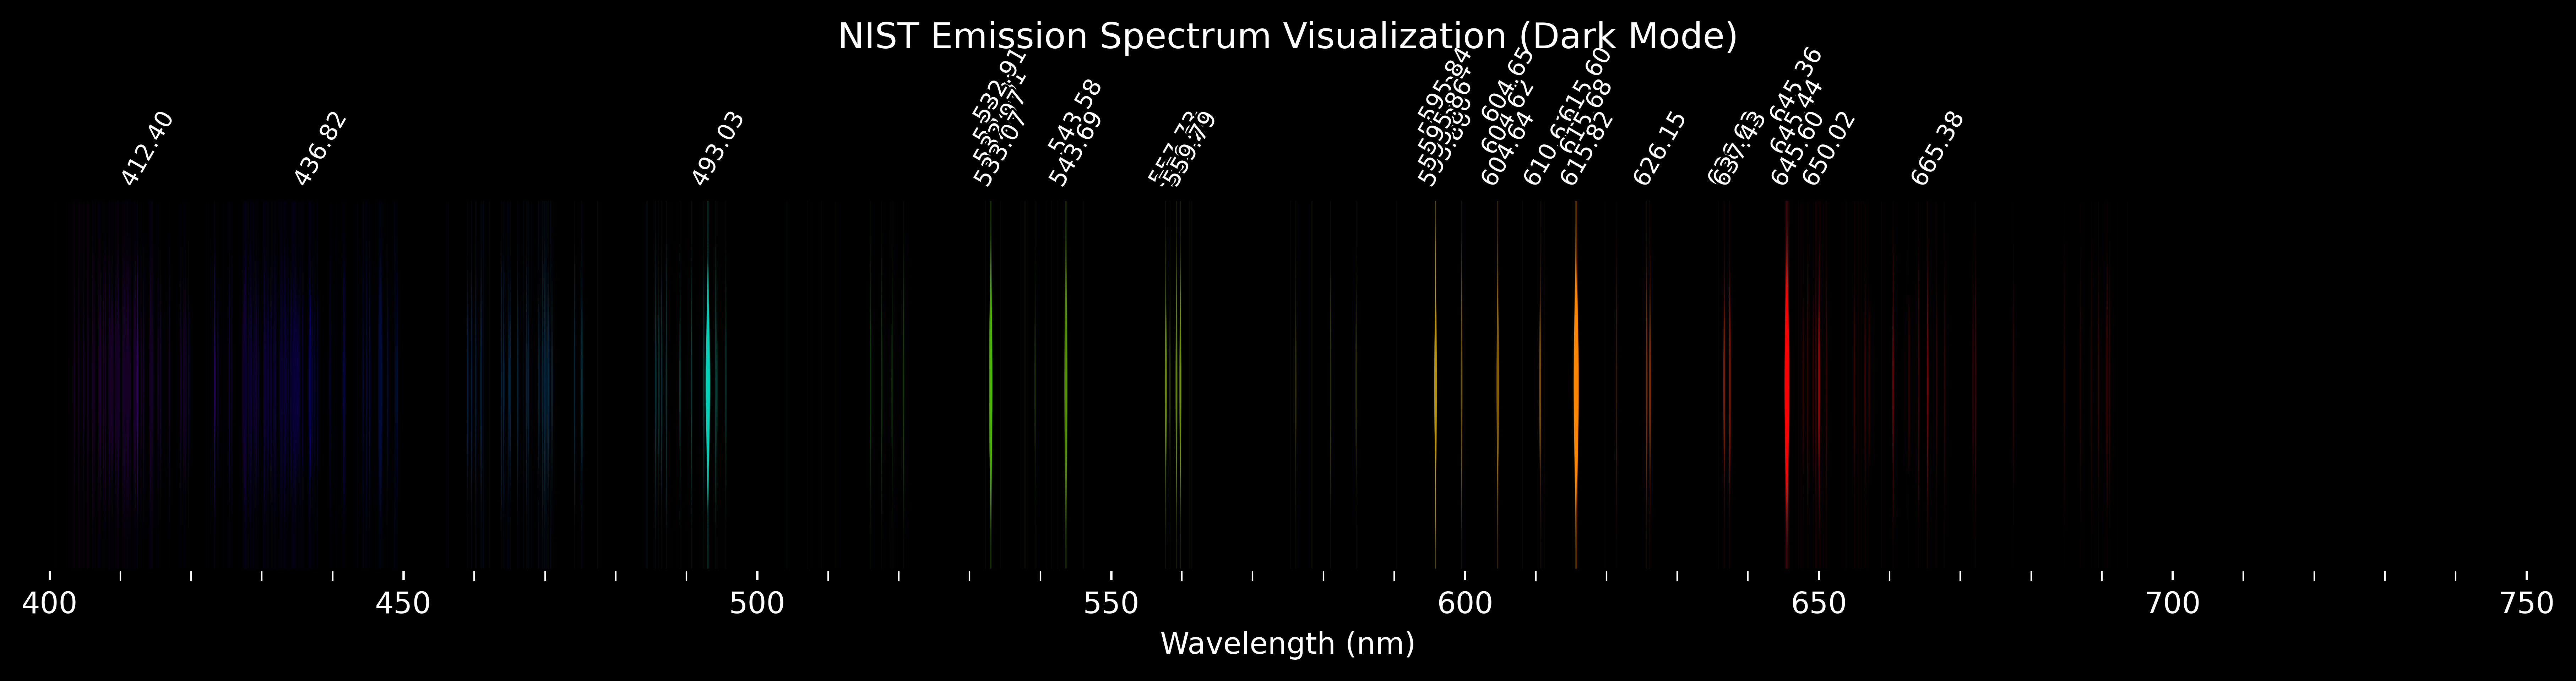

In [ ]:
SHEET = "oxygen nist 2.xlsx"
d_df = pd.read_excel(SHEET)
plot_nist_spec(d_df)